<a href="https://colab.research.google.com/github/padelacruz85/DAF2026/blob/main/Milestone_1/%5BDATA_PREPROCESSING%5D_MotorPH_Sales_Data-3rd_Quarter-Year_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MotorPH Sales Data (3rd Quarter 2025) – Data Preprocessing**

Source: `[RAW_DATA]_MotorPH_Sales Data-3rd Quarter-Year 2025.csv`  
Reference: `[CLEANED_DATA]_MotorPH_Products_List_2025.csv` (cleaned product list)  
Output: `[CLEANED_DATA]_MotorPH_Sales_Data-3rd_Quarter-Year_2025.csv`

In [1]:
# Connecting to google drive (Colab). Outside Colab this step is skipped automatically.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print("Running in Colab:", IN_COLAB)

Running in Colab: False


In [2]:
# Import libraries
import os, re
import numpy as np                 # arithmetic and statistical computations
import pandas as pd                # data wrangling and manipulation
import matplotlib.pyplot as plt    # Basic Data Viz
import seaborn as sns              # Intermediate Statistical Data Viz

In [3]:
# Load Data Sets
# Folder in Google Drive that holds the CSV files (edit if yours is different)
DRIVE_DIR = "/content/drive/MyDrive/4thYR_Term1/MO-IT106 - Data Analytics Fundamentals/Week 05/Dataset Preprocessing/"
GITHUB    = "https://raw.githubusercontent.com/padelacruz85/DAF2026/main/"
SALES_FILE = "[RAW_DATA]_MotorPH_Sales Data-3rd Quarter-Year 2025.csv"
PROD_FILES = ["[CLEANED_DATA]_MotorPH_Products_List_2025.csv", "[PROCESSED_DATA]_MotorPH_Products_List_2025.csv"]

def locate(fname, folder):
    # Google Drive first, then local folders, then the GitHub repo.
    for p in [DRIVE_DIR + fname, fname, f"{folder}/{fname}", f"../{folder}/{fname}"]:
        if os.path.exists(p):
            return p
    return GITHUB + folder + "/" + fname.replace("[", "%5B").replace("]", "%5D").replace(" ", "%20")

sales_path = locate(SALES_FILE, "Raw_Data")
df_sales = pd.read_csv(sales_path)
df_raw = df_sales.copy()          # untouched backup for before/after comparison
print("Sales data loaded from:", sales_path)

# Cleaned product list = reference catalogue (product names, IDs, list prices)
prod_path = next((locate(f, "Milestone_1") for f in PROD_FILES
                  if os.path.exists(DRIVE_DIR + f) or os.path.exists(f) or os.path.exists("Milestone_1/" + f)
                  or os.path.exists("../Milestone_1/" + f)), locate(PROD_FILES[0], "Milestone_1"))
df_prod = pd.read_csv(prod_path)
print("Product list loaded from:", prod_path, df_prod.shape)

Sales data loaded from: Raw_Data/[RAW_DATA]_MotorPH_Sales Data-3rd Quarter-Year 2025.csv
Product list loaded from: Milestone_1/[CLEANED_DATA]_MotorPH_Products_List_2025.csv (50, 10)


# **1. INSPECTING THE DATA SET**

In [4]:
df_sales.head(10)

,date,client_type,product,unitprice,quantity,total,payment
0,7/22/2025,Retail,Zontes GK350,269000,20,5380000,Cash
1,6/15/2025,Wholesale,Yamaha FZi 150,99900,18,1798200,Credit card
2,8/11/2025,Wholesale,Zontes GK350,269000,41,11029000,Credit card
3,7/31/2025,Retail,Italjet Dragster 200,867000,50,14450000,Cash
4,6/21/2025,Wholesale,Zontes 310X,248000,7,1736000,Cash
5,8/22/2025,Retail,Zontes 310X,248000,3,744000,Cash
6,8/26/2025,Retail,Yamaha Aerox 155,124000,28,3472000,Credit card
7,8/14/2025,NaN,KTM 790 Duke,599000,14,8386000,Cash
8,8/14/2025,Retail,Bajaj Dominar 400,199900,12,2398800,Transfer
9,8/27/2025,Wholesale,KTM 790 Duke,599000,46,27554000,Credit card


In [5]:
df_sales.tail(10)

,date,client_type,product,unitprice,quantity,total,payment
990,6/10/2025,Wholesale,CFMoto 650MT,345000,22,7590000,Transfer
991,7/14/2025,Wholesale,Moto Guzzi V7 Stone,689000,11,7579000,Credit card
992,6/2/2025,Retail,Yamaha FZi 150,99900,48,4795200,Cash
993,6/13/2025,Retail,Kawasaki KLX 230,199000,4,796000,Credit card
994,7/10/2025,Wholesale,CFMoto 650MT,345000,18,6210000,Transfer
995,6/2/2025,Wholesale,Moto Morini X-Cape 650,369000,23,8487000,Credit card
996,8/23/2025,Retail,CFMoto 300NK,165000,2,330000,Credit card
997,8/4/2025,Retail,Suzuki Burgman Street 125,80900,46,3721400,Credit card
998,8/2/2025,Wholesale,Rusi Flash 125,48000,33,1584000,Cash
999,8/12/2025,Retail,SYM Jet X 150,128000,1,128000,Credit card


In [6]:
print("Rows, columns:", df_sales.shape)
df_sales.info()

Rows, columns: (1000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         998 non-null    str  
 1   client_type  990 non-null    str  
 2   product      1000 non-null   str  
 3   unitprice    1000 non-null   int64
 4   quantity     1000 non-null   int64
 5   total        1000 non-null   int64
 6   payment      990 non-null    str  
dtypes: int64(3), str(4)
memory usage: 54.8 KB


In [7]:
df_sales.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,998,98,8/1/2025,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_type,990,2,Retail,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,1000,63,Moto Guzzi V7 Stone,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unitprice,1000.0,NaN,NaN,NaN,266429.6,203772.753279,48000.0,125900.0,210000.0,340000.0,2067000.0
quantity,1000.0,NaN,NaN,NaN,17.749,13.307482,1.0,7.0,15.0,25.0,50.0
total,1000.0,NaN,NaN,NaN,4480788.4,4951405.896553,67900.0,1294400.0,2803300.0,6061500.0,32835000.0
payment,990,3,Credit card,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **2. DETECTING ISSUES**

In [8]:
# 2.1 Missing values (NaN, empty strings, whitespace-only)
print("NaN per column:\n", df_sales.isna().sum(), "\n")
txt = df_sales.select_dtypes(include=["object", "string"])
print("Blank strings per column:\n", txt.apply(lambda s: s.str.strip().eq("")).sum())
print("\nRows with at least one missing value:", df_sales.isna().any(axis=1).sum())
df_sales[df_sales.isna().any(axis=1)].head(15)

NaN per column:
 date            2
client_type    10
product         0
unitprice       0
quantity        0
total           0
payment        10
dtype: int64 

Blank strings per column:
 date           0
client_type    0
product        0
payment        0
dtype: int64

Rows with at least one missing value: 22


,date,client_type,product,unitprice,quantity,total,payment
7,8/14/2025,NaN,KTM 790 Duke,599000,14,8386000,Cash
65,NaN,Retail,Vespa Primavera 150,210000,31,6510000,Credit card
84,6/15/2025,NaN,KTM Duke 200,178000,15,2670000,Cash
119,6/28/2025,Wholesale,Kawasaki Ninja 400,340000,8,2720000,NaN
186,8/9/2025,NaN,Yamaha Sniper 155,125900,8,1007200,Credit card
215,6/1/2025,NaN,Harley-Davidson Street 750,499000,7,3493000,Cash
244,6/19/2025,Wholesale,KTM RC 200,198000,14,2772000,NaN
246,8/6/2025,NaN,Yamaha Aerox 155,124000,18,2232000,Transfer
311,7/3/2025,Wholesale,CFMoto 650MT,345000,3,1035000,NaN
318,7/8/2025,Wholesale,Keeway RKS 150 Sport,68900,15,1033500,NaN


In [9]:
# 2.2 Duplicates
print("Full-row duplicates:", df_sales.duplicated().sum())
print("Duplicates ignoring date (same product/qty/price/client/payment on different days):",
      df_sales.duplicated(subset=[c for c in df_sales.columns if c != "date"]).sum(), "(coincidences, not true duplicates)")

Full-row duplicates: 0
Duplicates ignoring date (same product/qty/price/client/payment on different days): 32 (coincidences, not true duplicates)


In [10]:
# 2.3 Data types and date formats
print(df_sales.dtypes, "\n")
# Convert every date to a pattern (9 = digit, a = letter) to reveal mixed formats
pattern = df_sales["date"].dropna().str.replace(r"\d", "9", regex=True).str.replace(r"[A-Za-z]", "a", regex=True)
fmt_counts = pattern.value_counts()
print(fmt_counts)
print("\nNon-standard date values:")
standard = pd.to_datetime(df_sales["date"], format="%m/%d/%Y", errors="coerce")
print(df_sales.loc[standard.isna() & df_sales["date"].notna(), "date"].value_counts())

date             str
client_type      str
product          str
unitprice      int64
quantity       int64
total          int64
payment          str
dtype: object 

date
9/99/9999      670
9/9/9999       320
99-99-99         2
9999/99/99       2
99/99/9999       1
9999-99-99       1
99-99-9999       1
aaa-99-9999      1
Name: count, dtype: int64

Non-standard date values:
date
07-25-25       2
2025/07/32     2
13/01/2025     1
2025-08-00     1
08-40-2025     1
Aug-10-2025    1
Name: count, dtype: int64


In [11]:
# 2.4 Categorical fields
for col in ["client_type", "payment"]:
    print(f"--- {col} ---")
    print(df_sales[col].value_counts(dropna=False), "\n")

--- client_type ---
client_type
Retail       521
Wholesale    469
NaN           10
Name: count, dtype: int64 

--- payment ---
payment
Credit card    354
Transfer       328
Cash           308
NaN             10
Name: count, dtype: int64 



In [12]:
# 2.5 Product names vs. the cleaned product list
valid_products = set(df_prod["Product Name"])
unmatched = df_sales.loc[~df_sales["product"].isin(valid_products), "product"]
print("Distinct product names in sales:", df_sales["product"].nunique(), "| in product list:", len(valid_products))
print("Rows with a name not in the product list:", len(unmatched))
unmatched.value_counts()

Distinct product names in sales: 63 | in product list: 50
Rows with a name not in the product list: 15


product
Yamaha Serow 25x          2
KTM 790 Dukx              2
Suzuki Raider R150 Fx     1
Kawasaki KLX 23x          1
Bajaj CT12x               1
Yamaha Sniper 15x         1
Bristol Bobber 65x        1
Yamaha MT-1x              1
Benelli 502x              1
TVS Apache RTR 200 4x     1
Motorstar Xplorer 250x    1
CFMoto 300Sx              1
Honda ADV 16x             1
Name: count, dtype: int64

In [13]:
# 2.6 Consistency of unit price and total
print("total != unitprice x quantity :", (df_sales["total"] != df_sales["unitprice"] * df_sales["quantity"]).sum(), "rows")

list_price = df_sales["product"].map(df_prod.set_index("Product Name")["Unit Price (PHP)"])
chk = df_sales.assign(list_price=list_price).dropna(subset=["list_price"])
print("unitprice != catalogue price  :", (chk["unitprice"] != chk["list_price"]).sum(), "rows")
print("total != catalogue price x qty:", (chk["total"] != chk["list_price"] * chk["quantity"]).sum(), "rows")
bad = chk[chk["unitprice"] != chk["list_price"]].copy()
bad["price_ratio"] = (bad["unitprice"] / bad["list_price"]).round(2)
print("\nRatio of recorded price to catalogue price:\n", bad["price_ratio"].value_counts())
bad[["product", "unitprice", "list_price", "quantity", "total", "price_ratio"]].head(8)

total != unitprice x quantity : 20 rows
unitprice != catalogue price  : 19 rows
total != catalogue price x qty: 0 rows

Ratio of recorded price to catalogue price:
 price_ratio
3.0    19
Name: count, dtype: int64


,product,unitprice,list_price,quantity,total,price_ratio
3,Italjet Dragster 200,867000,289000.0,50,14450000,3.0
23,Keeway RKS 150 Sport,206700,68900.0,4,275600,3.0
38,Suzuki Raider R150 Fi,359700,119900.0,9,1079100,3.0
99,KTM Duke 200,534000,178000.0,7,1246000,3.0
113,Suzuki Burgman Street 125,242700,80900.0,5,404500,3.0
122,Bristol Veloce 500,984000,328000.0,12,3936000,3.0
131,Moto Guzzi V7 Stone,2067000,689000.0,4,2756000,3.0
139,Yamaha Sniper 155,377700,125900.0,8,1007200,3.0


       unitprice  quantity       total
count     1000.0    1000.0      1000.0
mean    266429.6      17.7   4480788.4
std     203772.8      13.3   4951405.9
min      48000.0       1.0     67900.0
25%     125900.0       7.0   1294400.0
50%     210000.0      15.0   2803300.0
75%     340000.0      25.0   6061500.0
max    2067000.0      50.0  32835000.0

Zero/negative values: {'unitprice': 0, 'quantity': 0, 'total': 0}


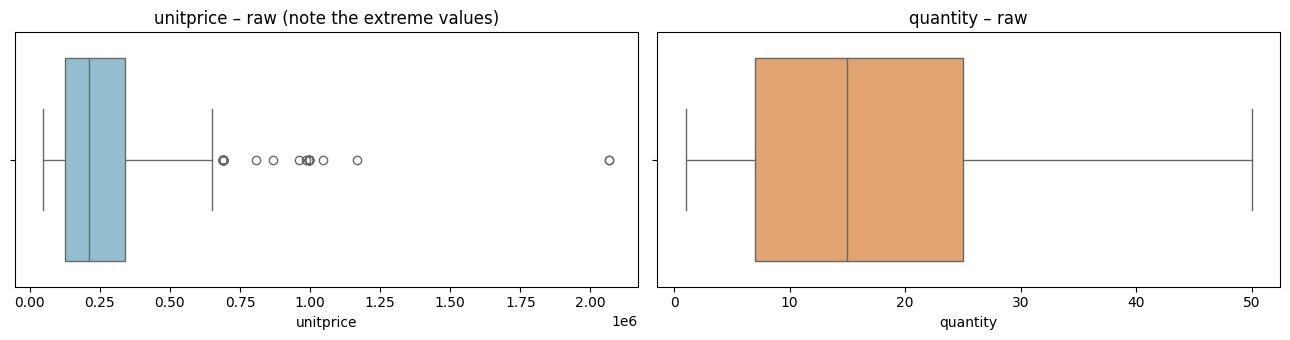

In [14]:
# 2.7 Ranges (quantity, price, total)
print(df_sales[["unitprice", "quantity", "total"]].describe().round(1))
print("\nZero/negative values:", (df_sales[["unitprice", "quantity", "total"]] <= 0).sum().to_dict())
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
sns.boxplot(x=df_sales["unitprice"], ax=axes[0], color="#89c2d9"); axes[0].set_title("unitprice – raw (note the extreme values)")
sns.boxplot(x=df_sales["quantity"],  ax=axes[1], color="#f4a261"); axes[1].set_title("quantity – raw")
plt.tight_layout(); plt.show()

### Findings
| # | Issue | Evidence |
|---|-------|----------|
| 1 | **Dates stored as text, in mixed formats** (`7/22/2025`, `07-25-25`, `Aug-10-2025`, `13/01/2025`) | pattern table in 2.3 |
| 2 | **Invalid dates** that cannot exist (`2025/07/32`, `2025-08-00`, `08-40-2025`) and **2 blank dates** | 2.1, 2.3 |
| 3 | **10 blank `client_type`** and **10 blank `payment`** values | 2.1 |
| 4 | **13 distinct product names are corrupted** (last character replaced by `x`, e.g. `Honda ADV 16x`, `Yamaha MT-1x`) – 15 rows that do not match the product list | 2.5 |
| 5 | **20 rows have a unit price exactly 3x the catalogue price** (19 are visible in 2.6; the 20th has a corrupted product name), while `total` still equals catalogue price x quantity – the unit price is wrong, the total is right | 2.6 |
| 6 | No full-row duplicates; no zero/negative quantity, price or total | 2.2, 2.7 |
| 7 | Column names are lower-case/unclear for reporting (`unitprice`, `total`, `payment`) | header row |

# **3. PREPROCESSING**

In [15]:
# 3.1 Work on a copy; trim whitespace and normalise spacing in all text fields
df = df_raw.copy()
for col in ["date", "client_type", "product", "payment"]:
    df[col] = df[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
print("Rows before cleaning:", len(df))

Rows before cleaning: 1000


In [16]:
# 3.2 Standardise category labels and handle missing categories
# Client type / payment cannot be inferred from other fields, so missing entries are kept as "Unknown"
# (this keeps the sales amounts in the analysis instead of discarding the whole transaction).
df["client_type"] = df["client_type"].str.title().fillna("Unknown")
df["payment"]     = df["payment"].str.title().fillna("Unknown")
print(df["client_type"].value_counts(), "\n")
print(df["payment"].value_counts())

client_type
Retail       521
Wholesale    469
Unknown       10
Name: count, dtype: Int64 

payment
Credit Card    354
Transfer       328
Cash           308
Unknown         10
Name: count, dtype: Int64


In [17]:
# 3.3 Repair corrupted product names
# A corrupted name differs from exactly ONE catalogue name by exactly ONE character; only unambiguous matches are fixed.
catalogue = list(df_prod["Product Name"])

def repair_name(name):
    if name in valid_products:
        return name
    cands = [p for p in catalogue if len(p) == len(name) and sum(a != b for a, b in zip(p, name)) == 1]
    return cands[0] if len(cands) == 1 else pd.NA

df["product_fixed"] = df["product"].map(repair_name)
mapping = (df.loc[df["product"] != df["product_fixed"], ["product", "product_fixed"]]
             .value_counts().rename("rows").reset_index())
print("Names that could not be repaired:", df["product_fixed"].isna().sum())
mapping

Names that could not be repaired: 0


,product,product_fixed,rows
0,Yamaha Serow 25x,Yamaha Serow 250,2
1,KTM 790 Dukx,KTM 790 Duke,2
2,Suzuki Raider R150 Fx,Suzuki Raider R150 Fi,1
3,Kawasaki KLX 23x,Kawasaki KLX 230,1
4,Bajaj CT12x,Bajaj CT125,1
5,Yamaha Sniper 15x,Yamaha Sniper 155,1
6,Bristol Bobber 65x,Bristol Bobber 650,1
7,Yamaha MT-1x,Yamaha MT-15,1
8,Benelli 502x,Benelli 502C,1
9,TVS Apache RTR 200 4x,TVS Apache RTR 200 4V,1


In [18]:
df["product"] = df["product_fixed"]
df = df.drop(columns="product_fixed")
print("All product names now in the product list:", df["product"].isin(valid_products).all())

All product names now in the product list: True


In [19]:
# 3.4 Standardise dates: try the known formats in order, then validate
DATE_FORMATS = ["%m/%d/%Y",   # standard in this file
                "%m-%d-%Y", "%m-%d-%y", "%b-%d-%Y", "%Y-%m-%d", "%Y/%m/%d",
                "%d/%m/%Y"]   # day-first is tried last so it can only rescue values the others cannot read

def parse_date(v):
    if pd.isna(v):
        return pd.NaT
    for f in DATE_FORMATS:
        try:
            return pd.to_datetime(v, format=f)
        except ValueError:
            continue
    return pd.NaT

df["date_parsed"] = df["date"].map(parse_date)

# Valid window = the period covered by the correctly formatted records
std_dates = pd.to_datetime(df_raw["date"], format="%m/%d/%Y", errors="coerce")
win_start, win_end = std_dates.min(), std_dates.max()
print("Sales period in the file:", win_start.date(), "to", win_end.date())

in_window = df["date_parsed"].between(win_start, win_end)
rescued = df.loc[(std_dates.isna().values) & in_window.values & df["date"].notna(), ["date", "date_parsed"]]
print("\nDates recovered from non-standard formats:")
print(rescued)

Sales period in the file: 2025-06-01 to 2025-08-31

Dates recovered from non-standard formats:
            date date_parsed
168     07-25-25  2025-07-25
705  Aug-10-2025  2025-08-10
741     07-25-25  2025-07-25


In [20]:
# Records whose date is missing, impossible, or outside the sales period cannot be placed in time -> removed
invalid = df[~in_window]
print("Rows removed (missing / invalid / out-of-period date):", len(invalid))
invalid[["date", "client_type", "product", "quantity", "total"]]

Rows removed (missing / invalid / out-of-period date): 7


,date,client_type,product,quantity,total
65,<NA>,Retail,Vespa Primavera 150,31,6510000
216,13/01/2025,Retail,Bajaj CT125,21,1425900
328,2025/07/32,Retail,Zontes GK350,9,2421000
370,<NA>,Wholesale,Suzuki Burgman Street 125,47,3802300
422,2025-08-00,Wholesale,Honda Rebel 1100,6,3900000
665,08-40-2025,Wholesale,Yamaha Sniper 155,18,2266200
913,2025/07/32,Retail,Yamaha Sniper 155,19,2392100


In [21]:
df = df[in_window].copy()
df["date"] = df["date_parsed"].dt.normalize()
df = df.drop(columns="date_parsed")
print("Rows remaining:", len(df), "| date range:", df["date"].min().date(), "to", df["date"].max().date())

Rows remaining: 993 | date range: 2025-06-01 to 2025-08-31


In [22]:
# 3.5 Correct unit price
# In 20 rows the recorded unit price is exactly 3x the catalogue price while the total matches catalogue price x quantity,
# so the unit price (not the total) is the wrong value. Restore it from the product list.
cat_price = df["product"].map(df_prod.set_index("Product Name")["Unit Price (PHP)"])
fixed = df.loc[df["unitprice"] != cat_price, ["product", "unitprice", "quantity", "total"]].assign(corrected_price=cat_price)
print("Unit prices corrected:", len(fixed))
df["unitprice"] = cat_price
print("unitprice x quantity == total for every row:", (df["unitprice"] * df["quantity"] == df["total"]).all())
fixed.head(10)

Unit prices corrected: 20
unitprice x quantity == total for every row: True


,product,unitprice,quantity,total,corrected_price
3,Italjet Dragster 200,867000,50,14450000,289000.0
23,Keeway RKS 150 Sport,206700,4,275600,68900.0
38,Suzuki Raider R150 Fi,359700,9,1079100,119900.0
99,KTM Duke 200,534000,7,1246000,178000.0
113,Suzuki Burgman Street 125,242700,5,404500,80900.0
122,Bristol Veloce 500,984000,12,3936000,328000.0
131,Moto Guzzi V7 Stone,2067000,4,2756000,689000.0
139,Yamaha Sniper 155,377700,8,1007200,125900.0
171,TVS Apache RTR 200 4V,387000,9,1161000,129000.0
185,CFMoto 300SR,495000,7,1155000,165000.0


In [23]:
# 3.6 Remove duplicates (safeguard – none expected after cleaning)
before = len(df)
df = df.drop_duplicates()
print("Duplicate rows removed:", before - len(df))

Duplicate rows removed: 0


In [24]:
# 3.7 Build the structured table: rename columns, correct types, sequential ID, column order
product_id = df["product"].map(df_prod.set_index("Product Name")["Product ID Number"])

df_clean = pd.DataFrame({
    "Date":              df["date"],
    "Client Type":       df["client_type"].astype("string"),
    "Product ID Number": product_id.astype("int64"),
    "Product Name":      df["product"].astype("string"),
    "Unit Price (PHP)":  df["unitprice"].astype("float64").round(2),
    "Quantity":          df["quantity"].astype("int64"),
    "Total Sales (PHP)": df["total"].astype("float64").round(2),
    "Payment Method":    df["payment"].astype("string"),
})

# Chronological order (stable sort keeps the original order within a day), then a sequential Transaction ID
df_clean = df_clean.sort_values("Date", kind="stable").reset_index(drop=True)
df_clean.insert(0, "Transaction ID", np.arange(1, len(df_clean) + 1))
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Transaction ID     993 non-null    int64         
 1   Date               993 non-null    datetime64[us]
 2   Client Type        993 non-null    string        
 3   Product ID Number  993 non-null    int64         
 4   Product Name       993 non-null    string        
 5   Unit Price (PHP)   993 non-null    float64       
 6   Quantity           993 non-null    int64         
 7   Total Sales (PHP)  993 non-null    float64       
 8   Payment Method     993 non-null    string        
dtypes: datetime64[us](1), float64(2), int64(3), string(3)
memory usage: 69.9 KB


# **4. VALIDATION (REVIEW PASS)**

In [25]:
checks = {
    "No missing values":                         df_clean.isna().sum().sum() == 0,
    "No duplicate rows":                         not df_clean.drop(columns="Transaction ID").duplicated().any(),
    "Transaction ID sequential 1..n":            (df_clean["Transaction ID"] == np.arange(1, len(df_clean) + 1)).all(),
    "Dates are valid datetimes":                 pd.api.types.is_datetime64_any_dtype(df_clean["Date"]),
    "All dates in 2025 sales period":            df_clean["Date"].between(win_start, win_end).all(),
    "Every product name is in product list":     df_clean["Product Name"].isin(valid_products).all(),
    "Product ID matches product name":           (df_clean["Product ID Number"] == df_clean["Product Name"].map(df_prod.set_index("Product Name")["Product ID Number"])).all(),
    "Unit price equals catalogue price":         (df_clean["Unit Price (PHP)"] == df_clean["Product Name"].map(df_prod.set_index("Product Name")["Unit Price (PHP)"])).all(),
    "Total = unit price x quantity":             (df_clean["Unit Price (PHP)"] * df_clean["Quantity"] == df_clean["Total Sales (PHP)"]).all(),
    "Quantity, price, total > 0":                (df_clean[["Quantity", "Unit Price (PHP)", "Total Sales (PHP)"]] > 0).all().all(),
    "No leading/trailing spaces":                all((df_clean[c] == df_clean[c].str.strip()).all() for c in df_clean.select_dtypes("string").columns),
}
for k, v in checks.items():
    print(f"{k:42s}: {v}")
print("\nClient Type :", df_clean["Client Type"].value_counts().to_dict())
print("Payment     :", df_clean["Payment Method"].value_counts().to_dict())

No missing values                         : True
No duplicate rows                         : True
Transaction ID sequential 1..n            : True
Dates are valid datetimes                 : True
All dates in 2025 sales period            : True
Every product name is in product list     : True
Product ID matches product name           : True
Unit price equals catalogue price         : True
Total = unit price x quantity             : True
Quantity, price, total > 0                : True
No leading/trailing spaces                : True

Client Type : {'Retail': 517, 'Wholesale': 466, 'Unknown': 10}
Payment     : {'Credit Card': 350, 'Transfer': 327, 'Cash': 306, 'Unknown': 10}


In [26]:
# Before / after summary
summary = pd.DataFrame({
    "Raw": [len(df_raw), df_raw.isna().sum().sum(), df_raw["product"].nunique(), (df_raw["unitprice"] * df_raw["quantity"] != df_raw["total"]).sum(), df_raw["total"].sum()],
    "Cleaned": [len(df_clean), df_clean.isna().sum().sum(), df_clean["Product Name"].nunique(), (df_clean["Unit Price (PHP)"] * df_clean["Quantity"] != df_clean["Total Sales (PHP)"]).sum(), df_clean["Total Sales (PHP)"].sum()],
}, index=["Rows", "Missing values", "Distinct products", "Rows where total != price x qty", "Total sales (PHP)"])
summary.style.format("{:,.0f}") if hasattr(summary, "style") else summary

,Raw,Cleaned
Rows,"1,000",993
Missing values,22,0
Distinct products,63,50
Rows where total != price x qty,20,0
Total sales (PHP),"4,480,788,400","4,458,070,900"


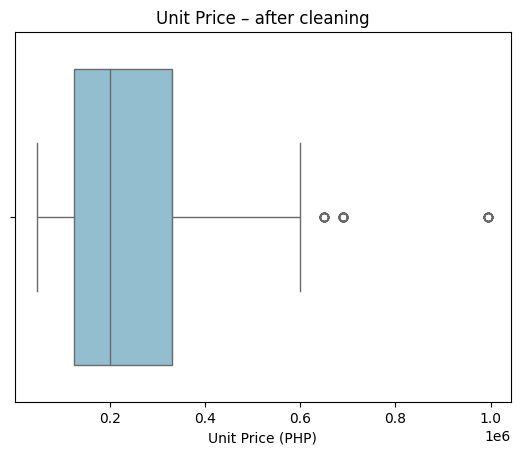

,Transaction ID,Date,Client Type,Product ID Number,Product Name,Unit Price (PHP),Quantity,Total Sales (PHP),Payment Method
0,1,2025-06-01,Wholesale,43,KTM 790 Duke,599000.0,9,5391000.0,Transfer
1,2,2025-06-01,Retail,27,Yamaha Sniper 155,125900.0,8,1007200.0,Cash
2,3,2025-06-01,Retail,29,Honda CRF300L,284900.0,32,9116800.0,Transfer
3,4,2025-06-01,Unknown,32,Harley-Davidson Street 750,499000.0,7,3493000.0,Cash
4,5,2025-06-01,Retail,43,KTM 790 Duke,599000.0,1,599000.0,Credit Card
5,6,2025-06-01,Wholesale,23,Keeway RKS 150 Sport,68900.0,12,826800.0,Transfer
6,7,2025-06-01,Retail,35,Yamaha XMAX 300,319000.0,26,8294000.0,Transfer
7,8,2025-06-01,Retail,19,Suzuki GSX-S150,125000.0,13,1625000.0,Cash
8,9,2025-06-01,Retail,21,Yamaha Aerox 155,124000.0,38,4712000.0,Cash
9,10,2025-06-01,Retail,28,Bajaj CT125,67900.0,6,407400.0,Credit Card


In [27]:
sns.boxplot(x=df_clean["Unit Price (PHP)"], color="#89c2d9")
plt.title("Unit Price – after cleaning"); plt.show()
df_clean.head(10)

# **5. EXPORT**

In [28]:
OUT_FILE = "[CLEANED_DATA]_MotorPH_Sales_Data-3rd_Quarter-Year_2025.csv"
df_clean.to_csv(OUT_FILE, index=False, encoding="utf-8")                       # saved in the Colab session
if IN_COLAB:
    df_clean.to_csv(DRIVE_DIR + OUT_FILE, index=False, encoding="utf-8")       # saved to Google Drive
    from google.colab import files
    files.download(OUT_FILE)                                                   # download to your computer
print("Saved:", OUT_FILE, df_clean.shape)

Saved: [CLEANED_DATA]_MotorPH_Sales_Data-3rd_Quarter-Year_2025.csv (993, 9)
